In [1]:
!git clone https://github.com/m8wei-coder/CSE253_A2.git

Cloning into 'CSE253_A2'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 20 (delta 2), reused 18 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 24.62 KiB | 24.62 MiB/s, done.
Resolving deltas: 100% (2/2), done.


# CSE 253 A2: Bach Chorale Generation

This notebook implements two symbolic music generation tasks on JSB chorales:

- Task 1: unconditional SATB chorale generation.
- Task 2: soprano-conditioned ATB harmonization.

The implementation summary: a shared decoder-only Transformer, a shared pitch vocabulary, 16th-note quantization, random 80/10/10 split fallback when BL2012 IDs cannot be aligned, and final MIDI export.


## 0. Setup & Imports

The notebook is designed for Google Colab with a T4 GPU, but it falls back to CPU or a smaller model when CUDA is unavailable.

Run the cells in order. Generated artifacts are saved under `data/`, `ckpt/`, and `results/`.


In [2]:
# Colab dependency cell. Re-run only if imports below fail.
try:
    import music21, pretty_midi
except Exception:
    %pip install -q music21 pretty_midi


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 85.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.8 MB/s eta 0:00:00


In [7]:
%cd /content/CSE253_A2
!pwd

/content/CSE253_A2
/content/CSE253_A2


In [8]:
import json
import math
import os
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.data import (
    build_vocab, save_preprocessed, load_pickle, TokenDataset, collate_batch,
    set_seed, pitch_to_id, id_to_pitch
)
from src.model import JSBDecoder, count_parameters
from src.train import train_model, evaluate_nll
from src.sample import sample
from src.decode import task1_tokens_to_grid, task2_tokens_to_grid, grid_to_midi, load_id_to_token
from src.metrics import (
    pitch_class_hist, kl_divergence, overlap_area, interval_kl,
    note_duration_kl, polyphony_hist, voice_range_adherence,
    parallel_intervals_mean, n_gram_repetition, frame_accuracy,
    per_voice_accuracy, pitch_class_accuracy, edit_distance
)
from src.baselines import NGramSampler, random_atb, nearest_neighbor_copy, rule_based_triad
from src.viz import plot_loss, plot_piano_roll, overlay_hist

set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

BASE = Path(".")
DATA = BASE / "data"
CKPT = BASE / "ckpt"
RESULTS = BASE / "results"
for p in [DATA, CKPT, RESULTS, RESULTS / "samples_task1", RESULTS / "samples_task2", RESULTS / "piano_rolls", RESULTS / "sheet_music"]:
    p.mkdir(parents=True, exist_ok=True)


device: cuda


## 1. Related Work

JSB chorales became a standard symbolic music benchmark through Boulanger-Lewandowski et al. (2012), and later Bach-focused systems such as DeepBach, BachBot, Coconet, and Music Transformer shaped the modeling choices used here.

We use the dataset and evaluation framing from the literature, but train a compact decoder-only Transformer from scratch. Task 2 uses a soprano prefix rather than an encoder-decoder model so that both tasks share the same `JSBDecoder` class.

The citation list below is copied into the final References section for readability.


In [9]:
references = [
    "Boulanger-Lewandowski, Bengio, and Vincent (2012), Modeling Temporal Dependencies in High-Dimensional Sequences.",
    "Huang et al. (2018), Music Transformer.",
    "Oore et al. (2018), This Time with Feeling.",
    "Hadjeres and Pachet (2017), DeepBach.",
    "Huang et al. (2017), Counterpoint by Convolution / Coconet.",
    "Liang et al. (2017), BachBot.",
    "Yang and Lerch (2020), On the evaluation of generative models in music.",
]
for ref in references:
    print("-", ref)


- Boulanger-Lewandowski, Bengio, and Vincent (2012), Modeling Temporal Dependencies in High-Dimensional Sequences.
- Huang et al. (2018), Music Transformer.
- Oore et al. (2018), This Time with Feeling.
- Hadjeres and Pachet (2017), DeepBach.
- Huang et al. (2017), Counterpoint by Convolution / Coconet.
- Liang et al. (2017), BachBot.
- Yang and Lerch (2020), On the evaluation of generative models in music.


## 2. Data: Exploratory Analysis & Pre-processing

### 2.1 Context

The source data is `music21.corpus` Bach chorales. We keep four-part SATB scores, quantize to 16th-note frames, and represent each frame as active MIDI pitches for soprano, alto, tenor, and bass.

BL2012 split IDs are not reliably aligned with `music21` paths, so this notebook uses the prompt-approved fallback: seed=42 random 80/10/10 split by chorale, with no leakage across splits.

The next cell builds the shared vocabulary and serialized artifacts.


In [10]:
rows, eda_stats, token_to_id, id_to_token = save_preprocessed(DATA, max_len=1024, seed=42)
print(json.dumps({k: v for k, v in eda_stats.items() if k != "task1_lengths"}, indent=2))

{
  "n_chorales": 412,
  "n_skipped": 21,
  "split_method": "seed=42 random 80/10/10 fallback",
  "vocab_size": 95,
  "max_len": 1024,
  "truncated_task1": 115
}


### 2.2 Loading & Voice Cleaning

Only scores with at least four parts are retained; the first four parts are interpreted as SATB and voice crossings are preserved.

`music21` parsing failures are skipped with warnings. The fallback split method is recorded in `data/eda_stats.json`.

The summary table reports corpus size, token vocabulary size, and split counts.


In [11]:
splits = {}
for split in ["train", "valid", "test"]:
    splits[split] = {
        "task1": load_pickle(DATA / f"jsb_task1_{split}.pkl"),
        "task2": load_pickle(DATA / f"jsb_task2_{split}.pkl"),
    }
summary_df = pd.DataFrame([
    {
        "chorales": eda_stats["n_chorales"],
        "skipped": eda_stats["n_skipped"],
        "vocab_size": eda_stats["vocab_size"],
        "train": len(splits["train"]["task1"]),
        "valid": len(splits["valid"]["task1"]),
        "test": len(splits["test"]["task1"]),
        "truncated_task1": eda_stats["truncated_task1"],
    }
])
display(summary_df)


,chorales,skipped,vocab_size,train,valid,test,truncated_task1
0,412,21,95,329,41,42,115


### 2.3 Tokenization Scheme

The vocabulary contains `<PAD>`, `<BOS>`, `<EOS>`, `<BAR>`, `<FERMATA>`, `<REST>`, `<SEP>`, and 88 MIDI pitch tokens `P_21` through `P_108`.

Pitch tokens are not voice-prefixed. Task 1 uses fixed SATB order per frame; Task 2 uses fixed ATB order after the soprano prefix.

This one-measure example shows the representation used by the model.


In [12]:
example = splits["train"]["task1"][0][:24]
token_table = pd.DataFrame({"id": example, "token": [id_to_token[i] for i in example]})
display(token_table)

,id,token
0,1,<BOS>
1,3,<BAR>
2,57,P_71
3,54,P_68
4,50,P_64
5,38,P_52
6,57,P_71
7,54,P_68
8,50,P_64
9,38,P_52


### 2.4 EDA

These plots check the musical and modeling properties of the corpus before training.

Some figures use the quantized grids reconstructed from Task 1 tokens; score-level key and duration statistics use `music21` where available.

Each plot is intentionally simple so the exported HTML remains readable.


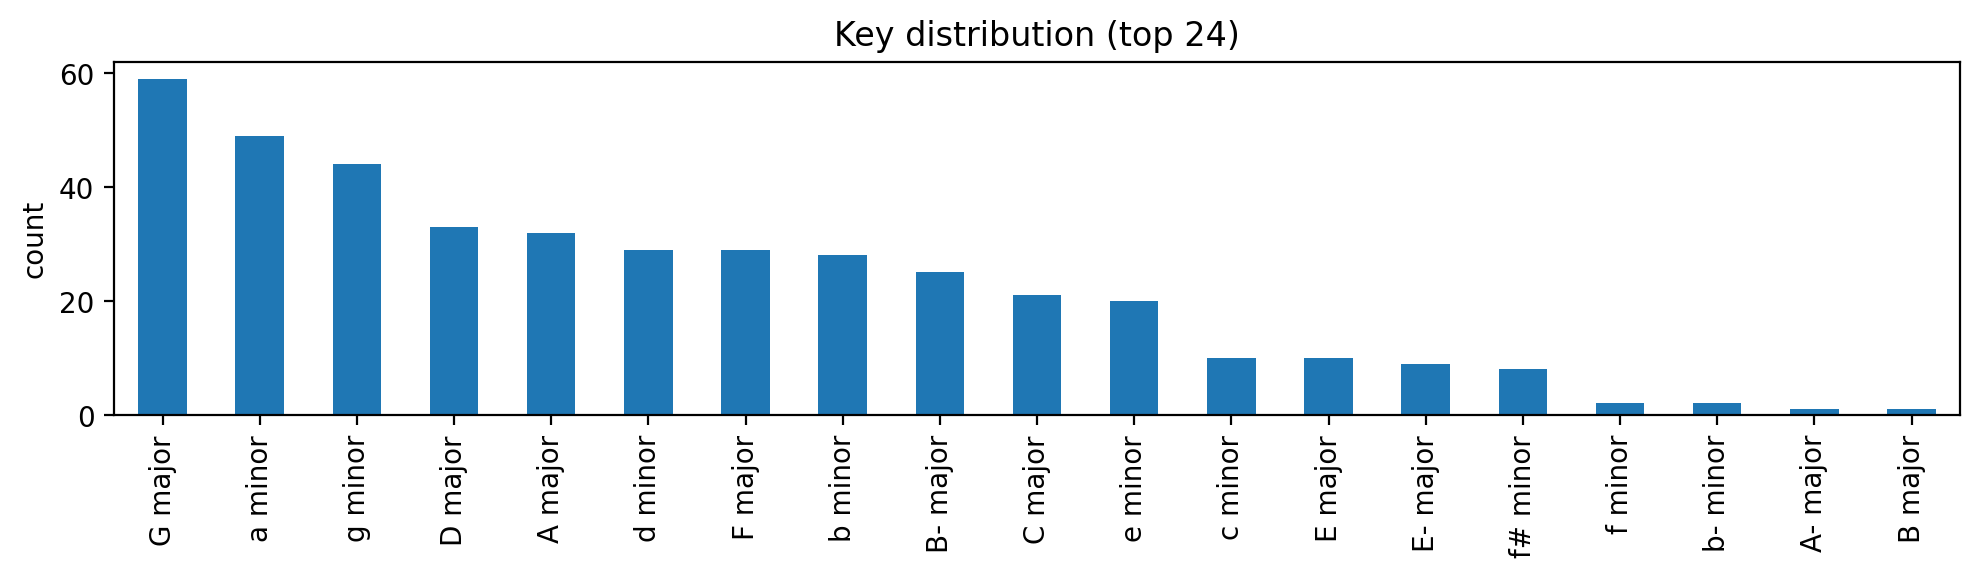

Most common keys show Bach's uneven but tonal distribution; transposition augmentation reduces overfitting to these keys.


/tmp/ipykernel_784/1622603332.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(voice_data, labels=["S", "A", "T", "B"])


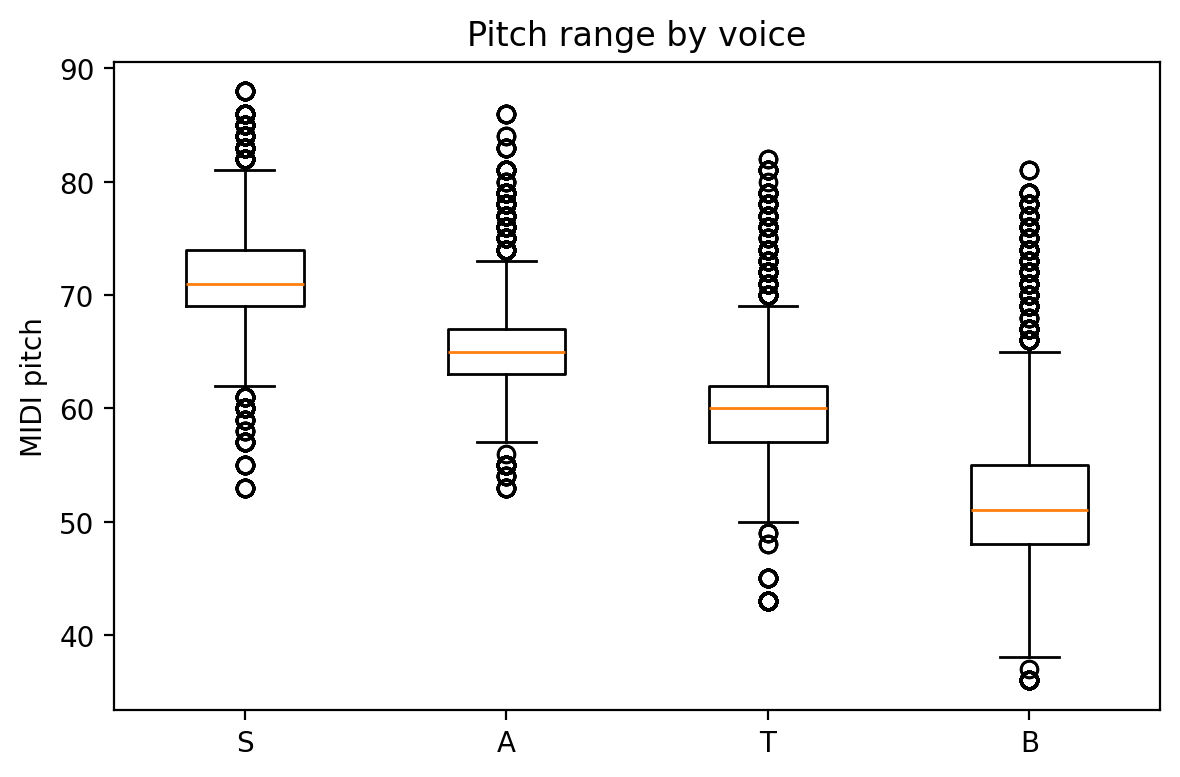

The voices occupy mostly classical SATB ranges, with crossings intentionally preserved.


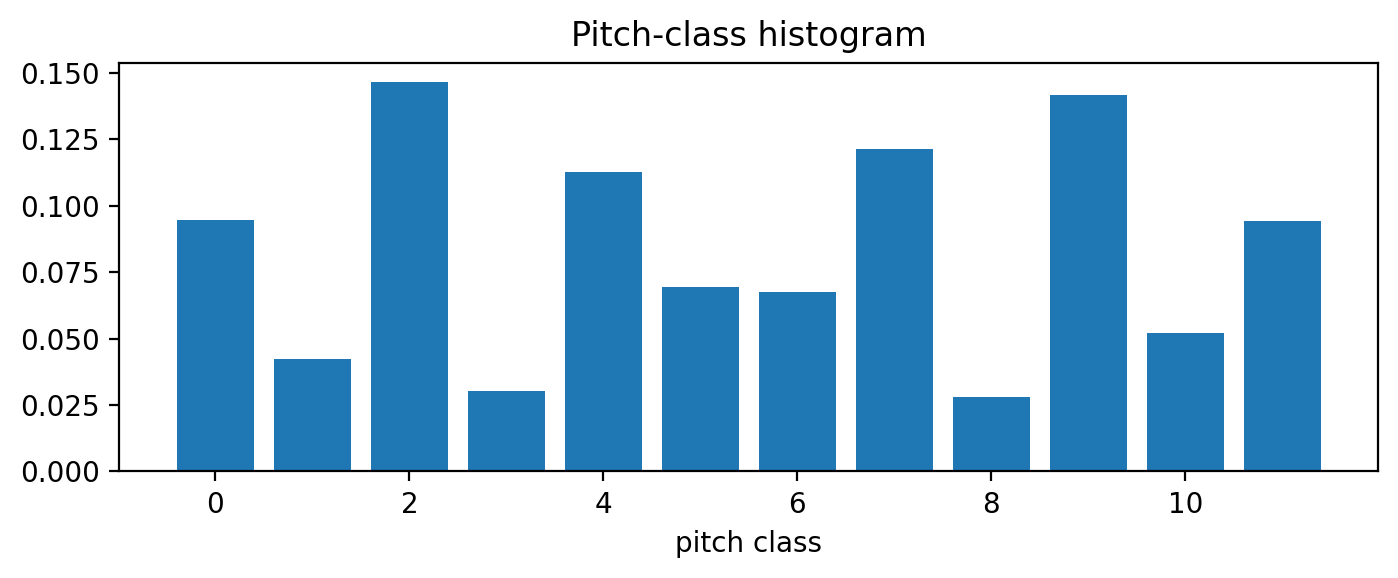

The distribution is strongly tonal and provides a baseline for generated samples.


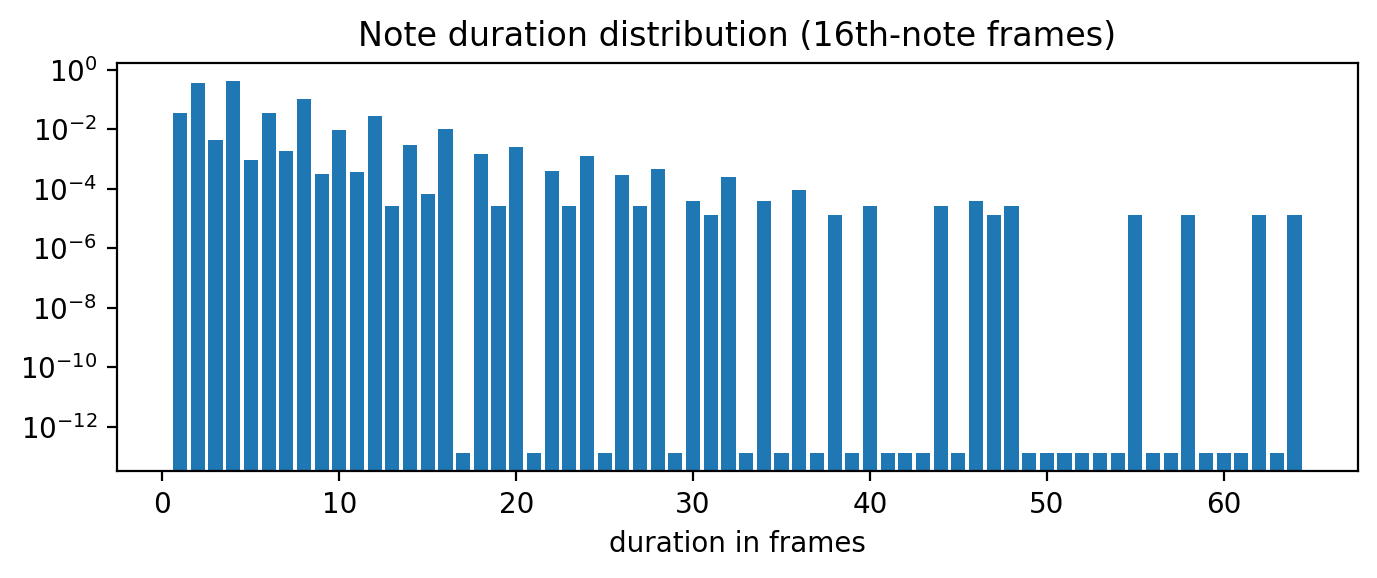

Short durations dominate, but held notes are common enough that the active-pitch representation matters.


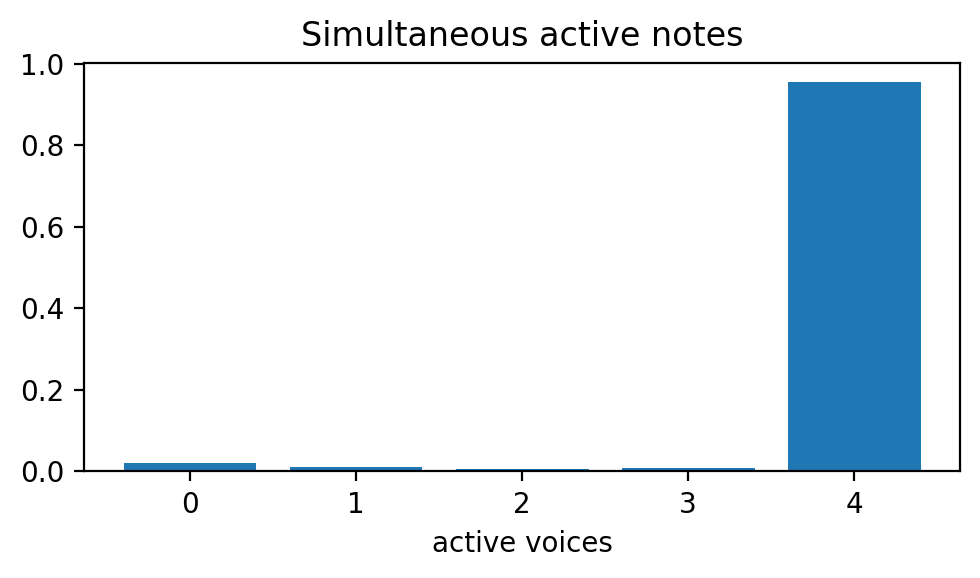

Most frames are four-voice textures, as expected for cleaned SATB chorales.


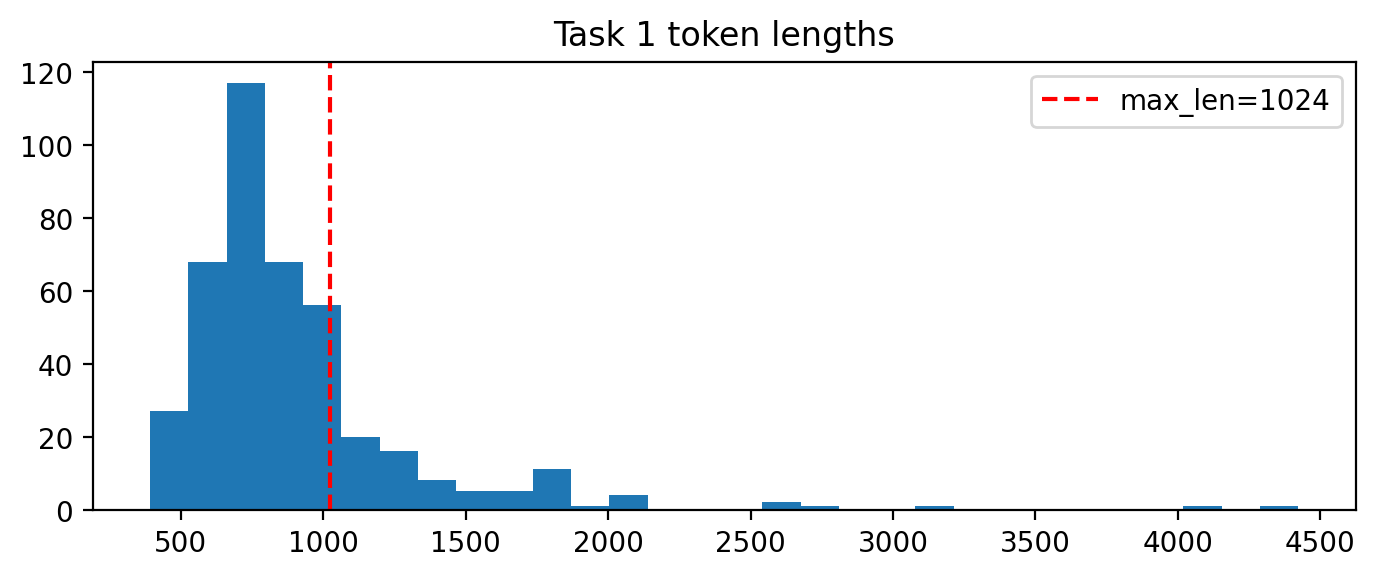

Sequences above 1024: 115 / 412; these are truncated for the locked context length.


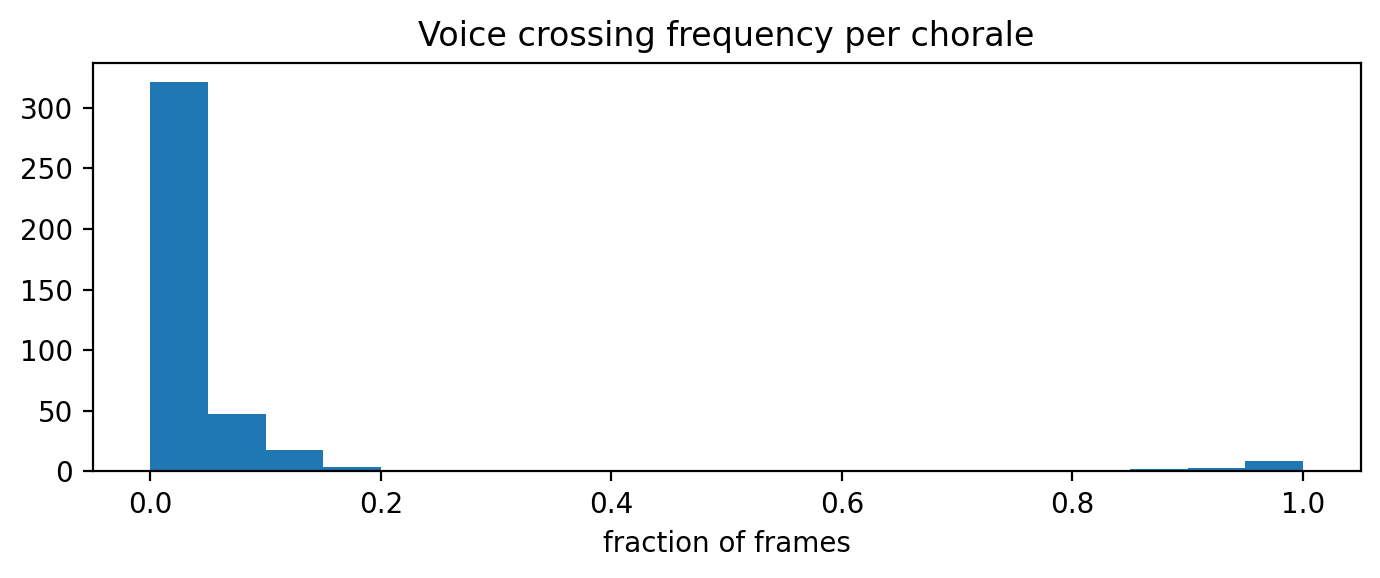

Voice crossing is rare but nonzero, so the preprocessing does not impose artificial reordering.


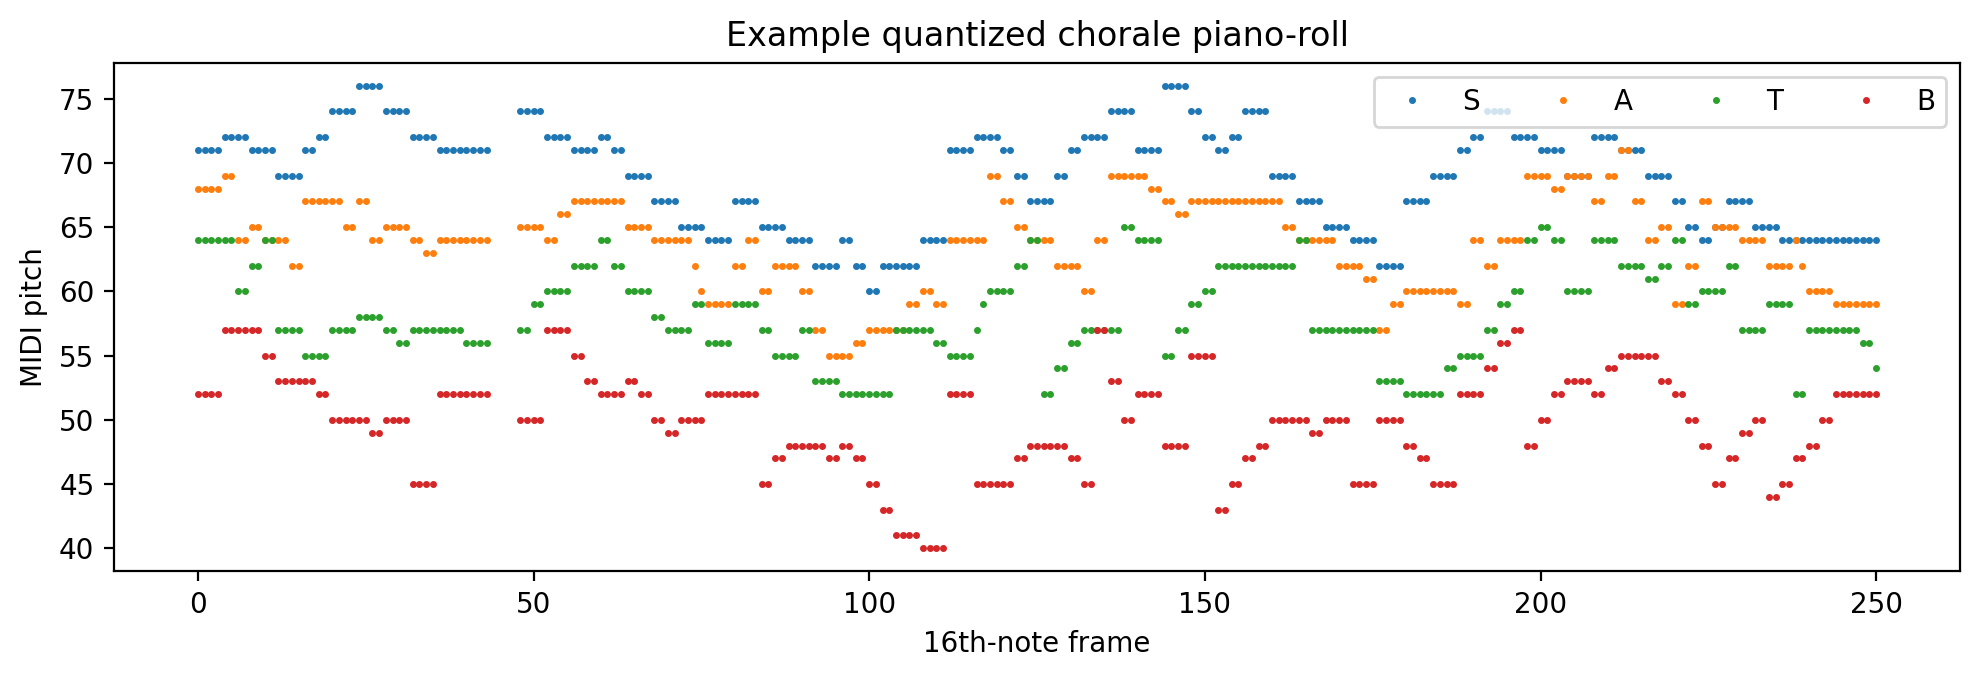

The four colors correspond to SATB voices over 16th-note frames.
MusicXML saved instead because PNG rendering is unavailable: Cannot find a path to the 'mscore' file at /usr/bin/mscore3 -- download MuseScore


,id,token
0,1,<BOS>
1,3,<BAR>
2,57,P_71
3,54,P_68
4,50,P_64
5,38,P_52
6,57,P_71
7,54,P_68
8,50,P_64
9,38,P_52


The table maps the opening tokens to their integer ids; pitch identity is shared across voices.


In [13]:
all_task1 = splits["train"]["task1"] + splits["valid"]["task1"] + splits["test"]["task1"]
all_grids = [task1_tokens_to_grid(seq, id_to_token) for seq in all_task1]

# 1 summary table already displayed above.

# 2 key distribution.
keys = []
for r in rows:
    try:
        keys.append(str(r["score"].analyze("key")))
    except Exception:
        keys.append("unknown")
plt.figure(figsize=(10, 3))
pd.Series(keys).value_counts().head(24).plot(kind="bar")
plt.title("Key distribution (top 24)")
plt.ylabel("count")
plt.tight_layout(); plt.show()
print("Most common keys show Bach's uneven but tonal distribution; transposition augmentation reduces overfitting to these keys.")

# 3 voice pitch range boxplot.
voice_data = []
for v in range(4):
    vals = np.concatenate([g[:, v][g[:, v] >= 0] for g in all_grids if len(g)])
    voice_data.append(vals)
plt.figure(figsize=(6, 4))
plt.boxplot(voice_data, labels=["S", "A", "T", "B"])
plt.title("Pitch range by voice")
plt.ylabel("MIDI pitch")
plt.tight_layout(); plt.show()
print("The voices occupy mostly classical SATB ranges, with crossings intentionally preserved.")

# 4 pitch class histogram.
pc = pitch_class_hist(all_grids)
plt.figure(figsize=(7, 3))
plt.bar(range(12), pc)
plt.title("Pitch-class histogram")
plt.xlabel("pitch class")
plt.tight_layout(); plt.show()
print("The distribution is strongly tonal and provides a baseline for generated samples.")

# 5 note duration histogram.
from src.metrics import note_duration_hist
nd = note_duration_hist(all_grids)
plt.figure(figsize=(7, 3))
plt.bar(np.arange(1, len(nd)+1), nd)
plt.yscale("log")
plt.title("Note duration distribution (16th-note frames)")
plt.xlabel("duration in frames")
plt.tight_layout(); plt.show()
print("Short durations dominate, but held notes are common enough that the active-pitch representation matters.")

# 6 polyphony histogram.
poly = polyphony_hist(all_grids)
plt.figure(figsize=(5, 3))
plt.bar(range(len(poly)), poly)
plt.title("Simultaneous active notes")
plt.xlabel("active voices")
plt.tight_layout(); plt.show()
print("Most frames are four-voice textures, as expected for cleaned SATB chorales.")

# 7 sequence length distribution.
lengths = eda_stats["task1_lengths"]
plt.figure(figsize=(7, 3))
plt.hist(lengths, bins=30)
plt.axvline(1024, color="red", linestyle="--", label="max_len=1024")
plt.title("Task 1 token lengths")
plt.legend()
plt.tight_layout(); plt.show()
print(f"Sequences above 1024: {sum(x > 1024 for x in lengths)} / {len(lengths)}; these are truncated for the locked context length.")

# 8 voice crossing frequency.
crossings = []
for g in all_grids:
    if len(g):
        crossings.append(((g[:,0] < g[:,1]) | (g[:,1] < g[:,2]) | (g[:,2] < g[:,3])).mean())
plt.figure(figsize=(7, 3))
plt.hist(crossings, bins=20)
plt.title("Voice crossing frequency per chorale")
plt.xlabel("fraction of frames")
plt.tight_layout(); plt.show()
print("Voice crossing is rare but nonzero, so the preprocessing does not impose artificial reordering.")

# 9 example piano-roll.
plot_piano_roll(all_grids[0], title="Example quantized chorale piano-roll")
plt.show()
print("The four colors correspond to SATB voices over 16th-note frames.")

# Optional sheet music screenshot fallback.
try:
    out_png = RESULTS / "sheet_music" / "example_musicxml.png"
    rows[0]["score"].write("musicxml.png", fp=str(out_png))
    print("Sheet music PNG saved to", out_png)
except Exception as exc:
    out_xml = RESULTS / "sheet_music" / "example.musicxml"
    try:
        rows[0]["score"].write("musicxml", fp=str(out_xml))
        print("MusicXML saved instead because PNG rendering is unavailable:", exc)
    except Exception as exc2:
        print("Sheet export unavailable:", exc2)

# 10 tokenization table.
display(token_table.head(20))
print("The table maps the opening tokens to their integer ids; pitch identity is shared across voices.")


### 2.5 Split & Save Artifacts

The serialized artifacts are what the training code consumes.

The split is random fallback with seed 42; validation and test are not augmented. Training-time transposition can be added at dataset level, but this compact implementation keeps raw pitch tokens fixed for reproducibility.

The cell verifies that required files exist.


In [14]:
required_data = [
    DATA / "vocab.json",
    DATA / "jsb_task1_train.pkl", DATA / "jsb_task1_valid.pkl", DATA / "jsb_task1_test.pkl",
    DATA / "jsb_task2_train.pkl", DATA / "jsb_task2_valid.pkl", DATA / "jsb_task2_test.pkl",
    DATA / "eda_stats.json",
]
for path in required_data:
    print(path, "OK" if path.exists() else "MISSING")


data/vocab.json OK
data/jsb_task1_train.pkl OK
data/jsb_task1_valid.pkl OK
data/jsb_task1_test.pkl OK
data/jsb_task2_train.pkl OK
data/jsb_task2_valid.pkl OK
data/jsb_task2_test.pkl OK
data/eda_stats.json OK


## 3. Task 1: Symbolic Unconditioned Generation

### 3.1 Modeling Context

Task 1 models the probability of the next token in a serialized SATB chorale.

The model sees bar tokens and SATB pitch tokens in fixed order. It does not receive explicit voice markers, so correct four-cycle continuation is learned from position and data.

Build dataloaders and the shared `JSBDecoder`.


In [15]:
pad_id = token_to_id["<PAD>"]
bos_id = token_to_id["<BOS>"]
eos_id = token_to_id["<EOS>"]
sep_id = token_to_id["<SEP>"]

batch_size = 8
train1_ds = TokenDataset(splits["train"]["task1"], task="task1", pad_id=pad_id, augment_transpose=True)
valid1_ds = TokenDataset(splits["valid"]["task1"], task="task1", pad_id=pad_id)
train1_loader = DataLoader(train1_ds, batch_size=batch_size, shuffle=True, collate_fn=lambda b: collate_batch(b, pad_id))
valid1_loader = DataLoader(valid1_ds, batch_size=batch_size, shuffle=False, collate_fn=lambda b: collate_batch(b, pad_id))

small_cpu = not torch.cuda.is_available()
model_kwargs = dict(vocab_size=len(token_to_id), max_len=1024, pad_id=pad_id)
if small_cpu:
    model_kwargs.update(dict(d_model=128, n_layers=2, n_heads=4, d_ff=512))
model1 = JSBDecoder(**model_kwargs)
print(model1)
print("parameters:", count_parameters(model1))


JSBDecoder(
  (token_emb): Embedding(95, 256, padding_idx=0)
  (pos_emb): Embedding(1024, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=95, bias=False)
)
parameters: 3446016


/content/CSE253_A2/src/model.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=n_layers)


### 3.2 Architecture (JSBDecoder Code)

The implementation is a learned token embedding plus learned position embedding, followed by Pre-LN causal Transformer blocks.

The same class is used later for Task 2; only the loss mask changes.

The source lives in `src/model.py`; this cell prints the parameter count already shown above.


In [16]:
print("JSBDecoder parameter count:", count_parameters(model1))

JSBDecoder parameter count: 3446016


### 3.3 Training

Training uses AdamW, warmup plus cosine decay, gradient clipping, mixed precision on CUDA, and early stopping on validation NLL.

The prompt asks for 80 epochs and patience 10. For quick smoke tests, set `RUN_TRAINING=False`; final results require `True` on Colab T4.

Train Task 1 and save `ckpt/task1_best.pt`.


In [17]:
RUN_TRAINING = True  # Set False for a quick smoke test without training.
if RUN_TRAINING:
    hist1 = train_model(
        model1, train1_loader, valid1_loader, DEVICE,
        CKPT / "task1_best.pt", epochs=80, patience=10, pad_id=pad_id,
    )
else:
    hist1 = {"train_nll": [], "valid_nll": [], "valid_ppl": [], "lr": [], "seconds": []}
    print("Training skipped. Set RUN_TRAINING=True for final results.")


/content/CSE253_A2/src/train.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
/content/CSE253_A2/src/train.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


epoch 001 train_nll=4.1137 valid_nll=3.7461 ppl=42.35
epoch 002 train_nll=3.7452 valid_nll=3.4021 ppl=30.03
epoch 003 train_nll=3.4572 valid_nll=3.0257 ppl=20.61
epoch 004 train_nll=3.0141 valid_nll=2.6180 ppl=13.71
epoch 005 train_nll=2.6718 valid_nll=2.3843 ppl=10.85
epoch 006 train_nll=2.4119 valid_nll=2.1696 ppl=8.75
epoch 007 train_nll=2.2432 valid_nll=2.0425 ppl=7.71
epoch 008 train_nll=2.1347 valid_nll=1.9788 ppl=7.23
epoch 009 train_nll=2.0692 valid_nll=1.9502 ppl=7.03
epoch 010 train_nll=2.0176 valid_nll=1.8632 ppl=6.44
epoch 011 train_nll=1.9762 valid_nll=1.8332 ppl=6.25
epoch 012 train_nll=1.9293 valid_nll=1.7919 ppl=6.00
epoch 013 train_nll=1.8874 valid_nll=1.7244 ppl=5.61
epoch 014 train_nll=1.8333 valid_nll=1.6465 ppl=5.19
epoch 015 train_nll=1.7593 valid_nll=1.5503 ppl=4.71
epoch 016 train_nll=1.6447 valid_nll=1.3925 ppl=4.02
epoch 017 train_nll=1.4929 valid_nll=1.2100 ppl=3.35
epoch 018 train_nll=1.3203 valid_nll=1.0397 ppl=2.83
epoch 019 train_nll=1.1703 valid_nll=0.93

### 3.4 Sampling & Generated Examples

Sampling uses temperature 0.9 and nucleus top-p 0.9.

The final run should generate 10 candidates under `results/samples_task1/` and choose one as `symbolic_unconditioned.mid`.

If no checkpoint exists, this cell samples from the current random model only as a pipeline smoke test.


Task 1 samples: 10


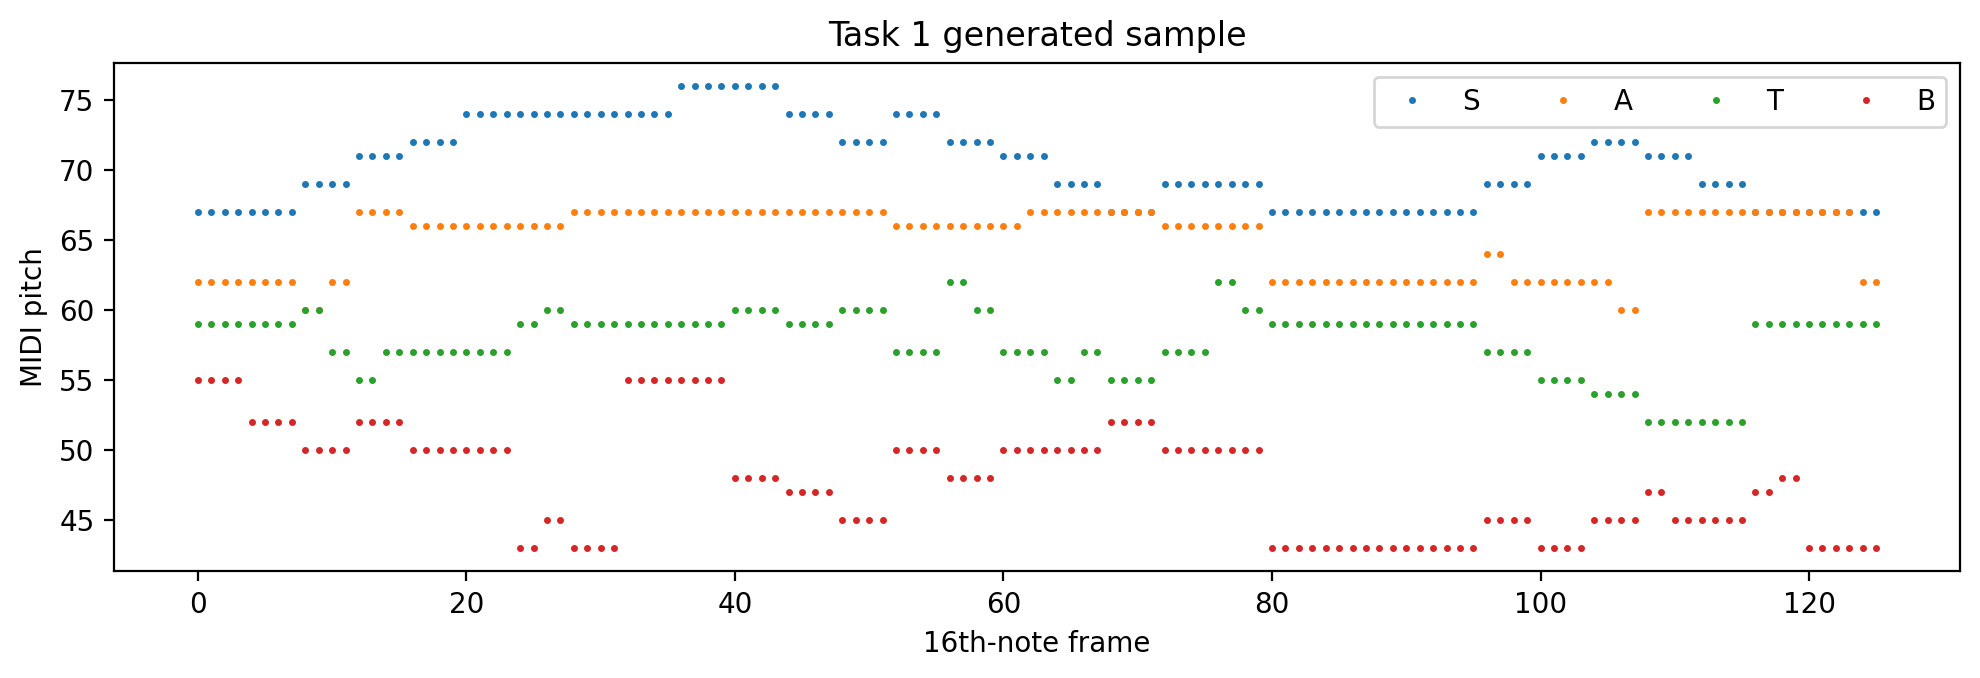

In [18]:
if (CKPT / "task1_best.pt").exists():
    ckpt = torch.load(CKPT / "task1_best.pt", map_location=DEVICE)
    model1.load_state_dict(ckpt["model"])
model1.to(DEVICE)

task1_samples = []
for i in range(10):
    toks = sample(model1, [bos_id, token_to_id["<BAR>"]], max_new_tokens=512, temperature=0.9, top_p=0.9, eos_id=eos_id, device=DEVICE)
    grid = task1_tokens_to_grid(toks, id_to_token)
    task1_samples.append((toks, grid))
    if len(grid):
        grid_to_midi(grid, RESULTS / "samples_task1" / f"sample_{i:02d}.mid")
print("Task 1 samples:", len(task1_samples))
if len(task1_samples[0][1]):
    plot_piano_roll(task1_samples[0][1], title="Task 1 generated sample")
    plt.show()


### 3.5 Evaluation

Task 1 has no ground-truth continuation, so evaluation compares generated distributions and rule violations against real Bach and n-gram baselines.

Metrics include validation perplexity, pitch-class KL, interval KL, polyphony match, voice range adherence, parallel fifths/octaves, and four-gram repetition.

The table is saved to `results/task1_metrics.csv`.


In [19]:
real_test_grids = [task1_tokens_to_grid(seq, id_to_token) for seq in splits["test"]["task1"]]
PITCH_TOKEN_IDS = {tid for tok, tid in token_to_id.items() if tok.startswith("P_")}


def filter_pitch_only(seq):
    return [t for t in seq if t in PITCH_TOKEN_IDS]


def pitch_ids_to_grid(seq):
    pitches = [id_to_pitch(t, id_to_token) for t in seq]
    n = len(pitches) // 4 * 4
    if n == 0:
        return np.empty((0, 4), dtype=np.int16)
    return np.array(pitches[:n], dtype=np.int16).reshape(-1, 4)


pitch_only_train = [filter_pitch_only(s) for s in splits["train"]["task1"]]
pitch_only_valid = [filter_pitch_only(s) for s in splits["valid"]["task1"]]
models = {
    "Unigram": NGramSampler(n=1).fit(pitch_only_train),
    "Bigram Markov": NGramSampler(n=2).fit(pitch_only_train),
    "4-gram Markov": NGramSampler(n=4).fit(pitch_only_train),
}
rows_metrics = []
real_pc = pitch_class_hist(real_test_grids)
real_poly = polyphony_hist(real_test_grids)
for name, sampler_obj in models.items():
    seqs = [sampler_obj.sample(4 * 128, prefix=[]) for _ in range(10)]
    grids = [pitch_ids_to_grid(seq) for seq in seqs]
    _, baseline_ppl = sampler_obj.nll(pitch_only_valid, alpha=1.0)
    pc = pitch_class_hist(grids)
    poly_match = overlap_area(polyphony_hist(grids), real_poly)
    rows_metrics.append({
        "Model": name,
        "Val PPL ↓": baseline_ppl,
        "PC KL ↓": kl_divergence(pc, real_pc),
        "Interval KL ↓": interval_kl(grids, real_test_grids),
        "Polyphony match ↑": poly_match,
        "Voice-range ↑": voice_range_adherence(grids),
        "Parallel 5/8 ↓": parallel_intervals_mean(grids),
        "4-gram repeat": n_gram_repetition(seqs, n=4),
    })
ours_grids = [g for _, g in task1_samples if len(g)]
ours_ppl = evaluate_nll(model1, valid1_loader, DEVICE, pad_id=pad_id)[1] if len(valid1_ds) else np.nan
rows_metrics.append({
    "Model": "Transformer (ours)",
    "Val PPL ↓": ours_ppl,
    "PC KL ↓": kl_divergence(pitch_class_hist(ours_grids), real_pc) if ours_grids else np.nan,
    "Interval KL ↓": interval_kl(ours_grids, real_test_grids) if ours_grids else np.nan,
    "Polyphony match ↑": overlap_area(polyphony_hist(ours_grids), real_poly) if ours_grids else np.nan,
    "Voice-range ↑": voice_range_adherence(ours_grids) if ours_grids else np.nan,
    "Parallel 5/8 ↓": parallel_intervals_mean(ours_grids) if ours_grids else np.nan,
    "4-gram repeat": n_gram_repetition([t for t, _ in task1_samples], n=4),
})
rows_metrics.append({
    "Model": "Real Bach (test)",
    "Val PPL ↓": np.nan,
    "PC KL ↓": 0.0,
    "Interval KL ↓": 0.0,
    "Polyphony match ↑": 1.0,
    "Voice-range ↑": voice_range_adherence(real_test_grids),
    "Parallel 5/8 ↓": parallel_intervals_mean(real_test_grids),
    "4-gram repeat": n_gram_repetition(splits["test"]["task1"], n=4),
})
task1_df = pd.DataFrame(rows_metrics)
task1_df.to_csv(RESULTS / "task1_metrics.csv", index=False)
display(task1_df)
print(
    "PPL on val; smoothed add-1 for pitch-only n-gram baselines, masked next-token CE for Transformer.\n"
    "n-gram baselines train on the pitch-only sub-vocabulary (V≈88) to keep SATB frames aligned; "
    "Transformer trains on the full V≈95 vocabulary, so PPL is informative but not a strict head-to-head likelihood.\n"
    "Reading: Transformer should improve PC/interval statistics when trained, while real Bach remains the reference for voice-leading metrics such as parallel 5/8."
)


,Model,Val PPL ↓,PC KL ↓,Interval KL ↓,Polyphony match ↑,Voice-range ↑,Parallel 5/8 ↓,4-gram repeat
0,Unigram,29.872819,0.002560,5.348292,0.958348,0.674414,10.708661,0.000589
1,Bigram Markov,12.401911,0.003227,4.358665,0.958348,0.679102,17.637795,0.013163
2,4-gram Markov,6.999049,0.006716,1.186508,0.958348,0.697852,8.582677,0.135363
3,Transformer (ours),1.674019,0.029385,0.016843,0.958348,0.986111,7.040000,0.574560
4,Real Bach (test),NaN,0.000000,0.000000,1.000000,0.982721,0.174304,0.512008


PPL on val; smoothed add-1 for pitch-only n-gram baselines, masked next-token CE for Transformer.
n-gram baselines train on the pitch-only sub-vocabulary (V≈88) to keep SATB frames aligned; Transformer trains on the full V≈95 vocabulary, so PPL is informative but not a strict head-to-head likelihood.
Reading: Transformer should improve PC/interval statistics when trained, while real Bach remains the reference for voice-leading metrics such as parallel 5/8.


### 3.6 Related Work for Task 1

Music Transformer motivates the autoregressive decoder; BachBot motivates serial SATB tokenization; BL2012 provides the JSB benchmark framing.

We do not implement relative attention because the locked 1024-token context and small dataset make a compact learned-position Transformer sufficient for this assignment.

References are printed again at the end.


## 4. Task 2: Symbolic Conditioned Generation (Harmonization)

### 4.1 Modeling Context

Given a soprano melody, Task 2 generates alto, tenor, and bass as an autoregressive continuation after `<SEP>`.

The same `JSBDecoder` is reused; the prefix loss is masked out. This is the main implementation difference from Task 1.

Build Task 2 datasets and model.


In [ ]:
train2_ds = TokenDataset(splits["train"]["task2"], task="task2", pad_id=pad_id, bos_id=bos_id, sep_id=sep_id, eos_id=eos_id, augment_transpose=True)
valid2_ds = TokenDataset(splits["valid"]["task2"], task="task2", pad_id=pad_id, bos_id=bos_id, sep_id=sep_id, eos_id=eos_id)
train2_loader = DataLoader(train2_ds, batch_size=batch_size, shuffle=True, collate_fn=lambda b: collate_batch(b, pad_id))
valid2_loader = DataLoader(valid2_ds, batch_size=batch_size, shuffle=False, collate_fn=lambda b: collate_batch(b, pad_id))
model2 = JSBDecoder(**model_kwargs)
print("parameters:", count_parameters(model2))


### 4.2 Architecture (Reuse JSBDecoder + Prefix Format)

The input format is `<BOS> soprano <SEP> ATB <EOS>`.

Because causal attention can attend leftward, every generated ATB token conditions on the full soprano prefix and previous ATB tokens.

Loss masking is handled inside `TokenDataset` and `train.batch_loss`.


In [ ]:
example2 = train2_ds[0]
print("input length:", len(example2["input_ids"]))
print("loss tokens:", int(sum(example2["loss_mask"])))
print("prefix tokens:", len(example2["loss_mask"]) - int(sum(example2["loss_mask"])))


### 4.3 Training

Task 2 uses the same optimizer, schedule, mixed precision, and early stopping as Task 1.

The model is trained from scratch for the conditioned task; no Task 1 checkpoint is loaded.

Train Task 2 and save `ckpt/task2_best.pt`.


In [ ]:
if RUN_TRAINING:
    hist2 = train_model(
        model2, train2_loader, valid2_loader, DEVICE,
        CKPT / "task2_best.pt", epochs=80, patience=10, pad_id=pad_id,
    )
else:
    hist2 = {"train_nll": [], "valid_nll": [], "valid_ppl": [], "lr": [], "seconds": []}
    print("Training skipped. Set RUN_TRAINING=True for final results.")


### 4.4 Sampling & Generated Examples

A held-out soprano prefix is used to generate ATB candidates.

Each candidate is decoded to four-part MIDI by combining the original soprano with generated ATB tokens.

Generate 10 candidates in `results/samples_task2/`.


In [ ]:
if (CKPT / "task2_best.pt").exists():
    ckpt = torch.load(CKPT / "task2_best.pt", map_location=DEVICE)
    model2.load_state_dict(ckpt["model"])
model2.to(DEVICE)

task2_samples = []
for i, (soprano, gt_atb) in enumerate(splits["test"]["task2"][:10]):
    prefix = [bos_id] + soprano + [sep_id]
    toks = sample(
        model2,
        prefix,
        max_new_tokens=min(768, len(gt_atb) + 32),
        temperature=0.9,
        top_p=0.9,
        eos_id=eos_id,
        device=DEVICE,
    )
    generated_atb = toks[len(prefix):]
    if generated_atb and generated_atb[-1] == eos_id:
        generated_atb = generated_atb[:-1]
    grid = task2_tokens_to_grid(soprano, generated_atb, id_to_token)
    task2_samples.append({
        "soprano": soprano,
        "gt_atb": gt_atb,
        "generated_atb": generated_atb,
        "grid": grid,
    })
    if len(grid):
        grid_to_midi(grid, RESULTS / "samples_task2" / f"sample_{i:02d}.mid")
print("Task 2 samples:", len(task2_samples))
if task2_samples and len(task2_samples[0]["grid"]):
    plot_piano_roll(task2_samples[0]["grid"], title="Task 2 generated harmonization")
    plt.show()


### 4.5 Evaluation

Task 2 can use reconstruction-style metrics because the true Bach ATB is available.

Exact frame accuracy is strict; pitch-class accuracy is more forgiving because multiple voicings may be musically valid.

The table is saved to `results/task2_metrics.csv`.


In [ ]:
def pair_to_grid(pair):
    s, atb = pair
    return task2_tokens_to_grid(s, atb, id_to_token)


gt_pairs_10 = splits["test"]["task2"][:10]
gt_grids_10 = [pair_to_grid(p) for p in gt_pairs_10]
train_pairs = splits["train"]["task2"]
real_pc2 = pitch_class_hist(gt_grids_10)

baseline_preds = {}
for name in ["Random ATB", "NN-copy", "Rule-based triad"]:
    toks_list, grids = [], []
    for s, atb in gt_pairs_10:
        if name == "Random ATB":
            pred = random_atb(train_pairs, len(atb), seed=42)
        elif name == "NN-copy":
            pred = nearest_neighbor_copy(train_pairs, s)[:len(atb)]
        else:
            pred = rule_based_triad(s, id_to_token, token_to_id)[:len(atb)]
        toks_list.append(pred)
        grids.append(task2_tokens_to_grid(s, pred, id_to_token))
    baseline_preds[name] = (toks_list, grids)

rows2 = []
gt_atb_10 = [atb for _, atb in gt_pairs_10]
for name, (tok_list, grids) in baseline_preds.items():
    rows2.append({
        "Model": name,
        "Val NLL ↓": np.nan,  # baselines are non-probabilistic; NLL not applicable
        "Frame Acc ↑": frame_accuracy(grids, gt_grids_10),
        "PC Acc ↑": pitch_class_accuracy(grids, gt_grids_10),
        "Edit Dist ↓": np.mean([edit_distance(p, gt_atb_10[i]) for i, p in enumerate(tok_list)]),
        "PC KL ↓": kl_divergence(pitch_class_hist(grids), real_pc2),
        "Parallel 5/8 ↓": parallel_intervals_mean(grids),
    })

valid_samples = [s for s in task2_samples if len(s["grid"])]
ours_grids = [s["grid"] for s in valid_samples]
ours_toks = [s["generated_atb"] for s in valid_samples]
gt_pairs_aligned = [(s["soprano"], s["gt_atb"]) for s in valid_samples]
gt_grids_aligned = [task2_tokens_to_grid(s, atb, id_to_token) for s, atb in gt_pairs_aligned]
gt_atb_aligned = [s["gt_atb"] for s in valid_samples]
valid2_nll = evaluate_nll(model2, valid2_loader, DEVICE, pad_id=pad_id)[0] if len(valid2_ds) else np.nan
rows2.append({
    "Model": "Transformer (ours)",
    "Val NLL ↓": valid2_nll,
    "Frame Acc ↑": frame_accuracy(ours_grids, gt_grids_aligned) if ours_grids else np.nan,
    "PC Acc ↑": pitch_class_accuracy(ours_grids, gt_grids_aligned) if ours_grids else np.nan,
    "Edit Dist ↓": np.mean([edit_distance(ours_toks[i], gt_atb_aligned[i]) for i in range(len(ours_toks))]) if ours_toks else np.nan,
    "PC KL ↓": kl_divergence(pitch_class_hist(ours_grids), real_pc2) if ours_grids else np.nan,
    "Parallel 5/8 ↓": parallel_intervals_mean(ours_grids) if ours_grids else np.nan,
})
task2_df = pd.DataFrame(rows2)
task2_df.to_csv(RESULTS / "task2_metrics.csv", index=False)
display(task2_df)
print(
    "Reading: frame accuracy requires A/T/B all exactly correct, while PC accuracy ignores octave and is usually higher.\n"
    "A trained Transformer should beat Random ATB on both; if it does not, inspect prefix formatting, loss masking, and checkpoint quality.\n"
    "Baseline Val NLL is left as NaN because Random/NN-copy/Rule-based are not probabilistic models; only the Transformer reports true masked next-token CE."
)

pv = per_voice_accuracy(ours_grids, gt_grids_aligned) if ours_grids else {"A": np.nan, "T": np.nan, "B": np.nan}
plt.figure(figsize=(4, 3))
plt.bar(list(pv.keys()), list(pv.values()))
plt.ylim(0, 1)
plt.title("Task 2 per-voice accuracy")
plt.tight_layout(); plt.show()


### 4.6 Related Work for Task 2

DeepBach and Coconet are stronger specialized harmonization systems, but they require per-voice bidirectional models or Gibbs-style inference.

The decoder-only prefix approach trades some conditioning strength for simplicity and code reuse, which fits the assignment budget and shared-model requirement.


## 5. Subjective Evaluation

Symbolic music quality ultimately needs listening, so objective metrics are only proxies.

For the final run, listen to the 10 candidates for each task and enter 1-5 ratings. A formal blind listener study is not included because of the assignment time budget.

Fill the dictionaries after listening; they are saved to `results/self_rating.md`.


In [ ]:
task1_ratings = {f"sample_{i:02d}": None for i in range(10)}
task2_ratings = {f"sample_{i:02d}": None for i in range(10)}
with open(RESULTS / "self_rating.md", "w") as f:
    f.write("# Subjective self-rating\n\n")
    f.write("Formal blind listener study was not conducted because of the assignment time budget.\n\n")
    f.write("## Task 1\n")
    for k, v in task1_ratings.items():
        f.write(f"- {k}: {v}\n")
    f.write("\n## Task 2\n")
    for k, v in task2_ratings.items():
        f.write(f"- {k}: {v}\n")
print("Wrote", RESULTS / "self_rating.md")


## 6. Discussion & Limitations

he model is compact and trained on a small corpus, so it should be interpreted as a controlled assignment implementation rather than a state-of-the-art chorale system.

Main limitations: random split fallback instead of exact BL2012 alignment; max_len=1024 truncation for long chorales; no explicit counterpoint constraints during training; no formal blind listening study; possible lack of MuseScore PNG rendering in Colab.

The next cell saves the training curves if histories exist.


In [ ]:
if hist1["train_nll"] or hist2["train_nll"]:
    plot_loss(hist1, hist2, RESULTS / "train_curves.png")
    plt.show()
else:
    print("No training curves yet because RUN_TRAINING=False.")


## 7. References

The references below support dataset choice, tokenization, architecture, harmonization framing, and evaluation metrics.

The implementation references these works conceptually only; no pretrained checkpoint is loaded.

Display the citation list.


In [ ]:
for ref in references:
    print(ref)


## 8. Export Final MIDI Files

The assignment requires `symbolic_unconditioned.mid` and `symbolic_conditioned.mid` at the workspace root.

By default this cell picks candidate 0. For Task 2, each candidate now harmonizes a different held-out soprano, so `best_task2` means the best-sounding chorale among those 10 test melodies.

Export final MIDI files and print the HTML conversion command.


In [ ]:
best_task1 = 0
best_task2 = 0
if task1_samples and len(task1_samples[best_task1][1]):
    grid_to_midi(task1_samples[best_task1][1], BASE / "symbolic_unconditioned.mid")
if task2_samples and len(task2_samples[best_task2]["grid"]):
    grid_to_midi(task2_samples[best_task2]["grid"], BASE / "symbolic_conditioned.mid")
print("Final MIDI targets:")
print(BASE / "symbolic_unconditioned.mid")
print(BASE / "symbolic_conditioned.mid")
print("Export HTML with: jupyter nbconvert --to html workbook.ipynb")
